# Direct Probing — Evaluation

Loads a pre-computed stage-2 judgments CSV produced by `run_direct_probing.py` and renders the evaluation figures. Does **not** re-run any inference.

Set `RUN_TAG` below to the run you want to evaluate (matches the `RUN_TAG` from `run_direct_probing.py`).

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "config" / "inference.example.yaml").exists():
            return p
    return Path.cwd()


# ---- Run identification ----
RUN_TAG = "direct_complete002"
EXPERIMENT_NAME = f"direct-probing-combined-{RUN_TAG}"

# ---- Paths ----
REPO_ROOT   = _repo_root()
OUTPUT_DIR  = REPO_ROOT / "logs" / "judges" / "direct-probing"
FIGURES_DIR = OUTPUT_DIR / "figures" / f"{RUN_TAG}-eval"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = OUTPUT_DIR / f"{EXPERIMENT_NAME}-stage2.judgments.csv"

print(f"Run        : {RUN_TAG}")
print(f"CSV        : {CSV_PATH}")
print(f"Figures →   : {FIGURES_DIR}")
assert CSV_PATH.exists(), f"Stage-2 CSV not found: {CSV_PATH}"

Run        : direct_complete002
CSV        : /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/direct-probing/direct-probing-combined-direct_complete002-stage2.judgments.csv
Figures →   : /Users/I570127/Documents/uniMA/Sem1/Teamproject/Investigating-Personalization-Effects-in-LLMs/logs/judges/direct-probing/figures/direct_complete002-eval


## 2. Load and prepare data

In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df_raw)} rows")
print(f"Status counts: {df_raw['status'].value_counts().to_dict()}")
print(f"Judges       : {df_raw['judge_alias'].unique().tolist()}")
print(f"Subject model: {df_raw['subject_model_alias'].unique().tolist()}")

# Keep only successful judgments; if multiple judges, take the first one consistently.
df = df_raw[df_raw["status"] == "success"].copy().reset_index(drop=True)
judge_aliases = sorted(df["judge_alias"].unique().tolist())
if len(judge_aliases) > 1:
    print(f"\nNote: multiple judges present, using first ({judge_aliases[0]})")
df = df[df["judge_alias"] == judge_aliases[0]].reset_index(drop=True)

# Parse metadata JSON -> true_gender / true_race
_meta = df["metadata"].apply(lambda s: json.loads(s) if isinstance(s, str) and s.strip() else {})
df["true_gender"] = _meta.apply(lambda d: d.get("true_gender"))
df["true_race"]   = _meta.apply(lambda d: d.get("true_race"))

# Split predicted class "<gender> - <race>"
df[["predicted_gender", "predicted_race"]] = df["final_class"].str.split(" - ", n=1, expand=True)

# Correctness flags
df["gender_correct"] = df["predicted_gender"] == df["true_gender"]
df["race_correct"]   = df["predicted_race"]   == df["true_race"]
df["both_correct"]   = df["gender_correct"] & df["race_correct"]

print(f"\nUsable rows: {len(df)}")
ALL_RACES = sorted(df["true_race"].dropna().unique().tolist())
print(f"Races ({len(ALL_RACES)}): {ALL_RACES}")

Loaded 736 rows
Status counts: {'success': 736}
Judges       : ['gpt-4o-mini_paid']
Subject model: ['gemma-4-31b_paid']

Usable rows: 736
Races (8): ['Central/Eastern Europe', 'France', 'Germany', 'Hispanic Countries', 'MENA', 'South/Central Asia', 'Sub-Saharan Africa', 'United Kingdom / North America']


## 3. Accuracy summary

In [3]:
sep = "=" * 50
print(f"{sep}\nGENDER PROBING\n{sep}")
print(f"Overall accuracy: {df['gender_correct'].mean():.1%}")
print("\nBy true gender:")
print(df.groupby("true_gender")["gender_correct"].agg(["mean", "count"]).to_string(float_format="{:.3f}".format))

print(f"\n{sep}\nRACE PROBING\n{sep}")
print(f"Overall accuracy: {df['race_correct'].mean():.1%}")
print(f"Chance level    : {1/len(ALL_RACES):.1%}")
print("\nBy true race:")
print(df.groupby("true_race")["race_correct"].agg(["mean", "count"]).sort_values("mean", ascending=False).to_string(float_format="{:.3f}".format))

print(f"\n{sep}\nCOMBINED (both correct)\n{sep}")
print(f"Overall: {df['both_correct'].mean():.1%}")

GENDER PROBING
Overall accuracy: 97.6%

By true gender:
             mean  count
true_gender             
Female      0.955    400
Male        1.000    336

RACE PROBING
Overall accuracy: 97.7%
Chance level    : 12.5%

By true race:
                                mean  count
true_race                                  
Central/Eastern Europe         1.000     92
Hispanic Countries             1.000     92
South/Central Asia             1.000     92
United Kingdom / North America 1.000     92
France                         0.989     92
Germany                        0.989     92
MENA                           0.935     92
Sub-Saharan Africa             0.902     92

COMBINED (both correct)
Overall: 96.2%


## 4. Confusion matrices

In [4]:
print("Gender confusion matrix:")
print(pd.crosstab(df["true_gender"], df["predicted_gender"], margins=True))
print("\nRace confusion matrix:")
print(pd.crosstab(df["true_race"], df["predicted_race"], margins=True))

Gender confusion matrix:
predicted_gender  Female  Male  All
true_gender                        
Female               382    18  400
Male                   0   336  336
All                  382   354  736

Race confusion matrix:
predicted_race                  Central/Eastern Europe  France  Germany  \
true_race                                                                 
Central/Eastern Europe                              92       0        0   
France                                               0      91        0   
Germany                                              0       0       91   
Hispanic Countries                                   0       0        0   
MENA                                                 0       0        0   
South/Central Asia                                   0       0        0   
Sub-Saharan Africa                                   0       0        0   
United Kingdom / North America                       0       0        0   
All                  

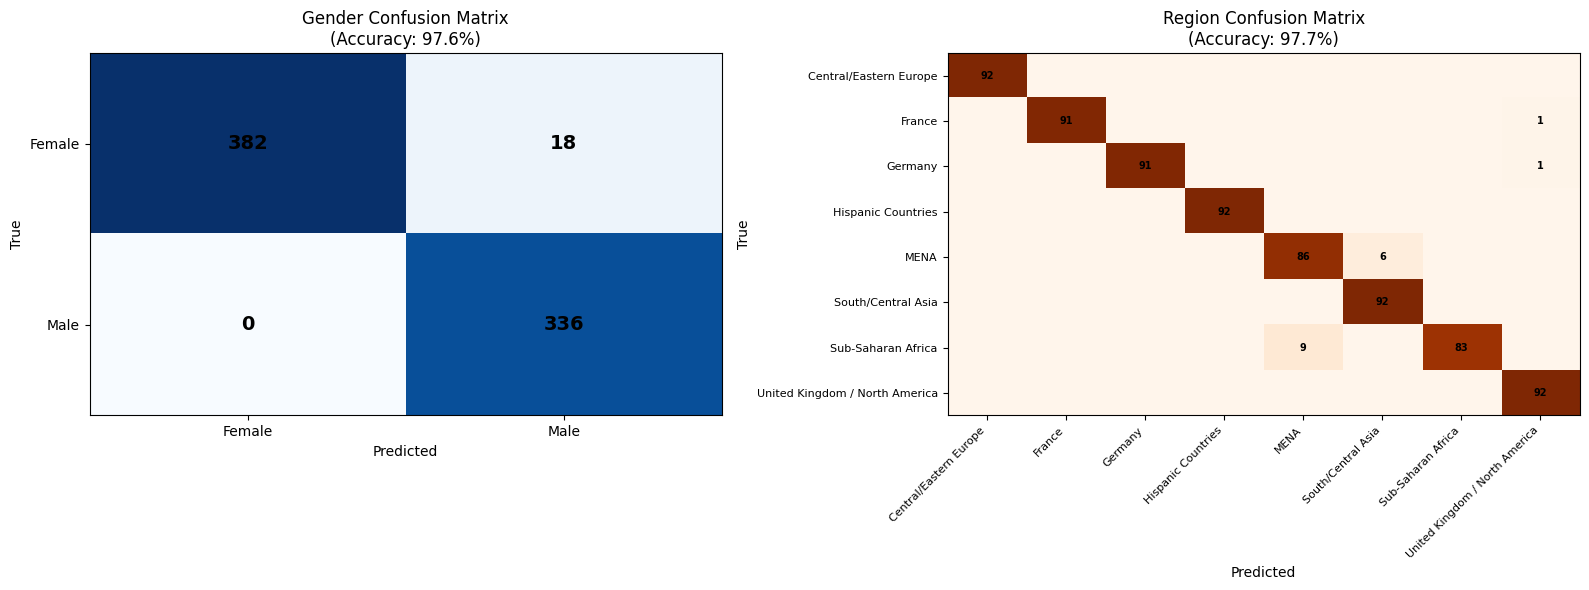

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gender ---
gender_ct = pd.crosstab(df["true_gender"], df["predicted_gender"])
ax = axes[0]
ax.imshow(gender_ct.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(gender_ct.columns)))
ax.set_yticks(range(len(gender_ct.index)))
ax.set_xticklabels(gender_ct.columns)
ax.set_yticklabels(gender_ct.index)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Gender Confusion Matrix\n(Accuracy: {df['gender_correct'].mean():.1%})")
for i in range(len(gender_ct.index)):
    for j in range(len(gender_ct.columns)):
        ax.text(j, i, str(gender_ct.values[i, j]), ha="center", va="center", fontsize=14, fontweight="bold")

# --- Race ---
race_ct = pd.crosstab(df["true_race"], df["predicted_race"])
race_ct = race_ct.reindex(index=ALL_RACES, columns=ALL_RACES, fill_value=0)
ax = axes[1]
ax.imshow(race_ct.values, cmap="Oranges", aspect="auto")
ax.set_xticks(range(len(race_ct.columns)))
ax.set_yticks(range(len(race_ct.index)))
ax.set_xticklabels(race_ct.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(race_ct.index, fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Region Confusion Matrix\n(Accuracy: {df['race_correct'].mean():.1%})")
for i in range(len(race_ct.index)):
    for j in range(len(race_ct.columns)):
        v = race_ct.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=7, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"confusion_matrices_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

## 5. Accuracy bars by group

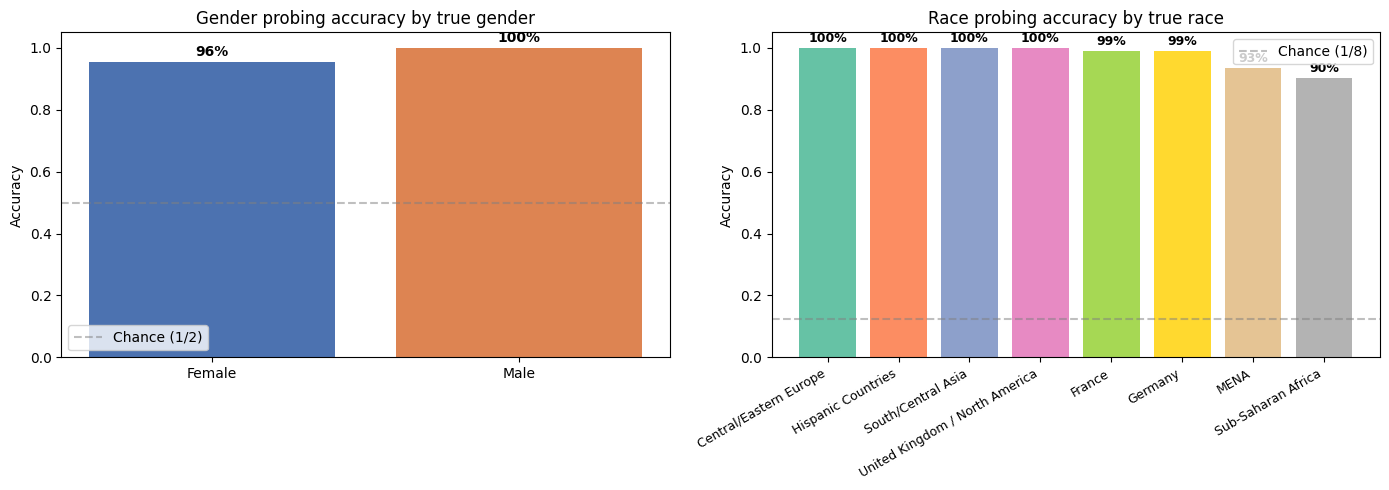

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gender accuracy by true gender ---
ax = axes[0]
gender_acc = df.groupby("true_gender")["gender_correct"].mean()
bars = ax.bar(gender_acc.index, gender_acc.values, color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Gender probing accuracy by true gender")
ax.axhline(0.5, ls="--", color="gray", alpha=0.5, label="Chance (1/2)")
for bar, val in zip(bars, gender_acc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold")
ax.legend()

# --- Race accuracy by true race ---
ax = axes[1]
race_acc = df.groupby("true_race")["race_correct"].mean().sort_values(ascending=False)
n_races = len(ALL_RACES)
bars = ax.bar(range(len(race_acc)), race_acc.values, color=plt.cm.Set2(np.linspace(0, 1, len(race_acc))))
ax.set_xticks(range(len(race_acc)))
ax.set_xticklabels(race_acc.index, rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Race probing accuracy by true race")
ax.axhline(1 / n_races, ls="--", color="gray", alpha=0.5, label=f"Chance (1/{n_races})")
for bar, val in zip(bars, race_acc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.0%}", ha="center", fontweight="bold", fontsize=9)
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"accuracy_bars_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Combined accuracy heatmap (gender × race)

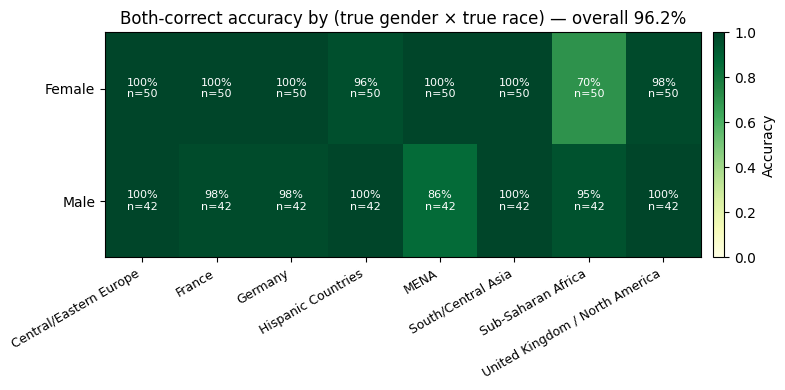

In [7]:
# both_correct rate per (true_gender × true_race) cell
combined = (
    df.groupby(["true_gender", "true_race"])["both_correct"]
      .agg(["mean", "count"])
      .reset_index()
)
pivot_mean  = combined.pivot(index="true_gender", columns="true_race", values="mean").reindex(columns=ALL_RACES)
pivot_count = combined.pivot(index="true_gender", columns="true_race", values="count").reindex(columns=ALL_RACES)

fig, ax = plt.subplots(figsize=(max(8, 0.9 * len(ALL_RACES)), 4))
im = ax.imshow(pivot_mean.values, cmap="YlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(ALL_RACES)))
ax.set_yticks(range(len(pivot_mean.index)))
ax.set_xticklabels(ALL_RACES, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(pivot_mean.index)
ax.set_title(f"Both-correct accuracy by (true gender × true race) — overall {df['both_correct'].mean():.1%}")
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        v = pivot_mean.values[i, j]
        n = pivot_count.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0%}\nn={int(n)}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.55 else "black")
plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="Accuracy")
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"combined_accuracy_{RUN_TAG}.png", bbox_inches="tight", dpi=150)
plt.show()